<a href="https://colab.research.google.com/github/Gaenariya/Kimnaryeong/blob/main/04_head_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

검출된 얼굴 수: 1


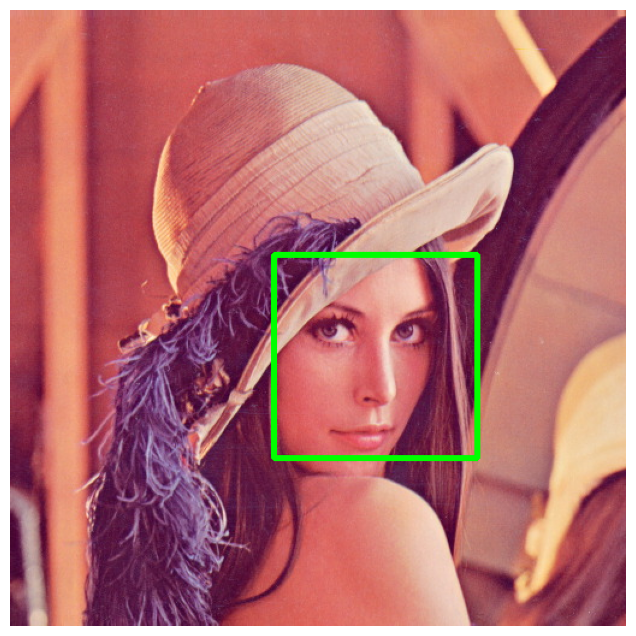

KeyboardInterrupt: 

In [1]:
# 04. OpenCV를 이용한 얼굴 검출 (Haar Cascade)
# Google Colab에 그대로 복사해서 셀 단위(# %%)로 실행하면 됩니다.

# %%
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# %% 샘플 이미지 다운로드 (직접 이미지를 업로드해도 됩니다)
!wget -q -O people.jpg https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg

# %% Haar Cascade 얼굴 검출기 불러오기 (OpenCV 내장 모델)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# %% 이미지 불러와서 얼굴 검출
img = cv2.imread("people.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
)
print(f"검출된 얼굴 수: {len(faces)}")

# %% 검출된 얼굴에 사각형 그리기
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 3)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

# %% (선택) 내 이미지로 직접 테스트하기 - Colab 파일 업로드
from google.colab import files
uploaded = files.upload()

for fname in uploaded.keys():
    my_img = cv2.imread(fname)
    my_gray = cv2.cvtColor(my_img, cv2.COLOR_BGR2GRAY)
    my_faces = face_cascade.detectMultiScale(my_gray, 1.1, 5, minSize=(30, 30))

    for (x, y, w, h) in my_faces:
        cv2.rectangle(my_img, (x, y), (x + w, y + h), (0, 255, 0), 3)

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(my_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()